# 🧠 Brain Tumor MRI Analyzer with Explainability
### A Two-Stage Deep Learning Pipeline: Classification + Segmentation + Grad-CAM

---

## 1. Introduction

Brain tumors are among the most life-threatening neurological conditions. Early and accurate detection from MRI scans is critical for treatment planning. However, manual inspection of MRI slices by radiologists is time-consuming and subject to human fatigue.

This project implements an automated two-stage deep learning pipeline:
1. **Classification** — EfficientNet-B0 fine-tuned to classify tumor type
2. **Segmentation** — U-Net with ResNet34 backbone for pixel-level tumor localization
3. **Explainability** — Grad-CAM heatmaps for interpretable predictions

### Research Foundation

| Paper | Contribution |
|---|---|
| Ronneberger et al. (2015) — *U-Net: Convolutional Networks for Biomedical Image Segmentation* | U-Net architecture used for segmentation |
| Selvaraju et al. (2017) — *Grad-CAM: Visual Explanations from Deep Networks* | Explainability heatmaps |
| BraTS Challenge (2018, 2020) | Benchmark for brain tumor segmentation |
| Tan & Le (2019) — *EfficientNet: Rethinking Model Scaling* | Classification backbone |

### Dataset
- **Kaggle Brain Tumor MRI Dataset** by Masoud Nickparvar
- 4 Classes: Glioma, Meningioma, Pituitary Tumor, No Tumor
- ~7,000 MRI images
- Link: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

## 2. Setup & Imports

In [4]:
# Install required libraries (run once)
%pip install torch torchvision segmentation-models-pytorch grad-cam streamlit opencv-python matplotlib seaborn scikit-learn Pillow numpy kaggle timm --quiet

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import segmentation_models_pytorch as smp
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 3. Dataset Download & Loading

In [9]:
# -------------------------------------------------------
# OPTION A: Kaggle API (recommended)
# Set your Kaggle credentials first:
#   export KAGGLE_USERNAME=your_username
#   export KAGGLE_KEY=your_api_key
# OR place kaggle.json in ~/.kaggle/
# -------------------------------------------------------
# !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
# !unzip brain-tumor-mri-dataset.zip -d archive (1)/

# -------------------------------------------------------
# OPTION B: Local archive already available in this workspace
# Use the extracted dataset under the archive folder.
# -------------------------------------------------------

DATA_DIR = Path('./archive (1)')
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR  = DATA_DIR / 'Testing'

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

print('Class mapping:', CLASS_LABELS)
print('Dataset root:', DATA_DIR.resolve())

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Dataset root: E:\PDS\New folder\brain_tumour_analysis\archive (1)


## 4. Exploratory Data Analysis (EDA)

Training set:
  glioma         : 1400
  meningioma     : 1400
  notumor        : 1400
  pituitary      : 1400
  Total          : 5600

Test set:
  glioma         : 400
  meningioma     : 400
  notumor        : 400
  pituitary      : 400


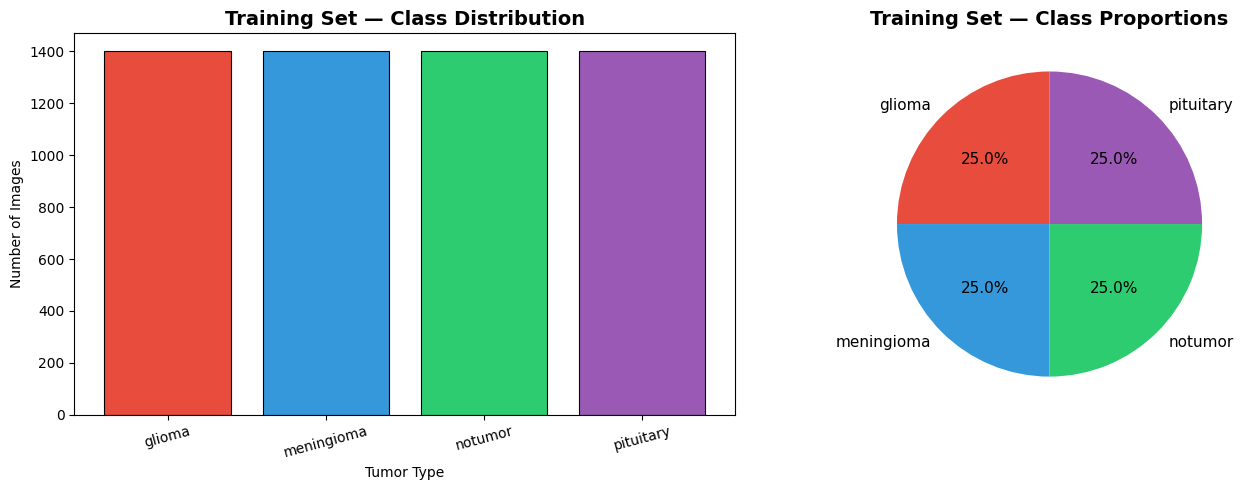

In [10]:
# Count images per class
train_counts = {cls: len(list((TRAIN_DIR / cls).glob('*.jpg'))) for cls in CLASS_NAMES}
test_counts  = {cls: len(list((TEST_DIR  / cls).glob('*.jpg'))) for cls in CLASS_NAMES}

print('Training set:')
for cls, count in train_counts.items():
    print(f'  {cls:15s}: {count}')
print(f'  {"Total":15s}: {sum(train_counts.values())}')

print('\nTest set:')
for cls, count in test_counts.items():
    print(f'  {cls:15s}: {count}')

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tumor Type')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(train_counts.values(), labels=train_counts.keys(), colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Training Set — Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

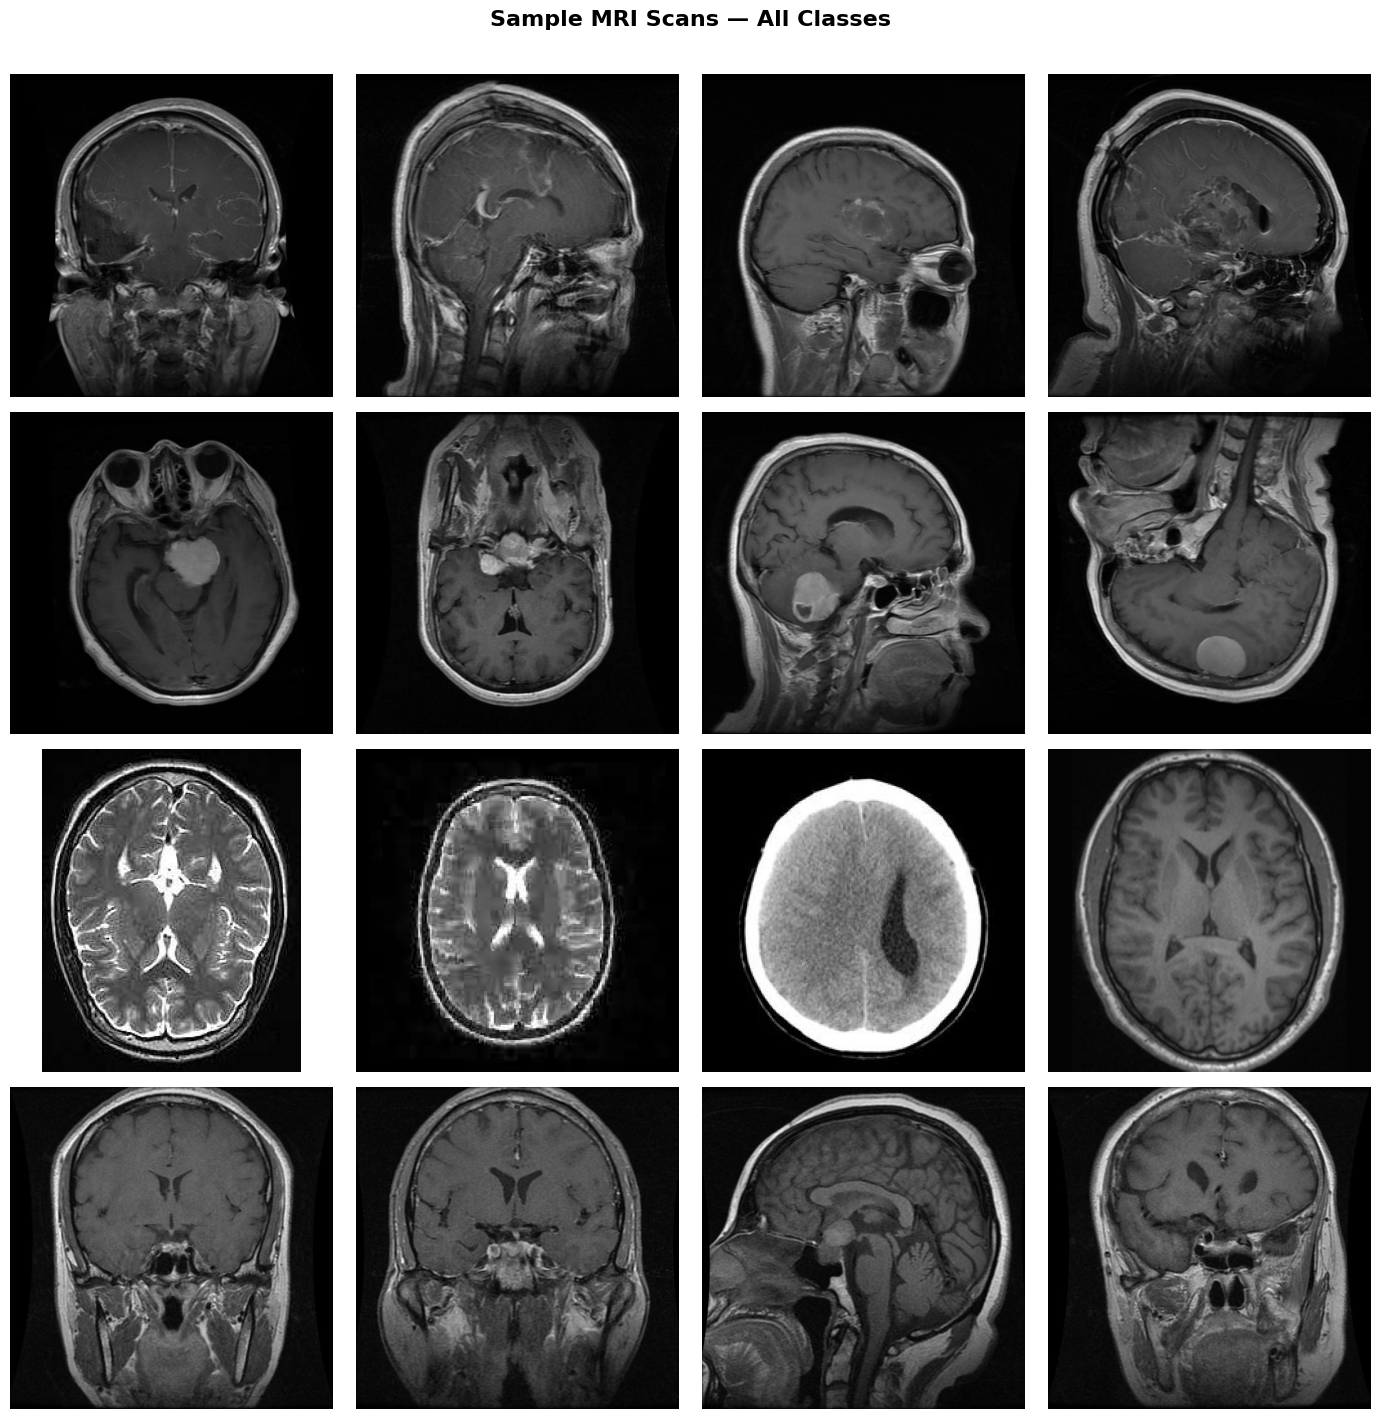

In [11]:
# Visualize sample MRI images from each class
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sample MRI Scans — All Classes', fontsize=16, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASS_NAMES):
    images = list((TRAIN_DIR / cls).glob('*.jpg'))[:4]
    for col_idx, img_path in enumerate(images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row_idx][col_idx].imshow(img, cmap='gray')
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(cls.upper(), fontsize=12, fontweight='bold', rotation=90, labelpad=10)
            axes[row_idx][col_idx].yaxis.set_label_position('left')
            axes[row_idx][col_idx].yaxis.label.set_visible(True)

plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing & Data Augmentation

Train: 4760 | Val: 840 | Test: 1600


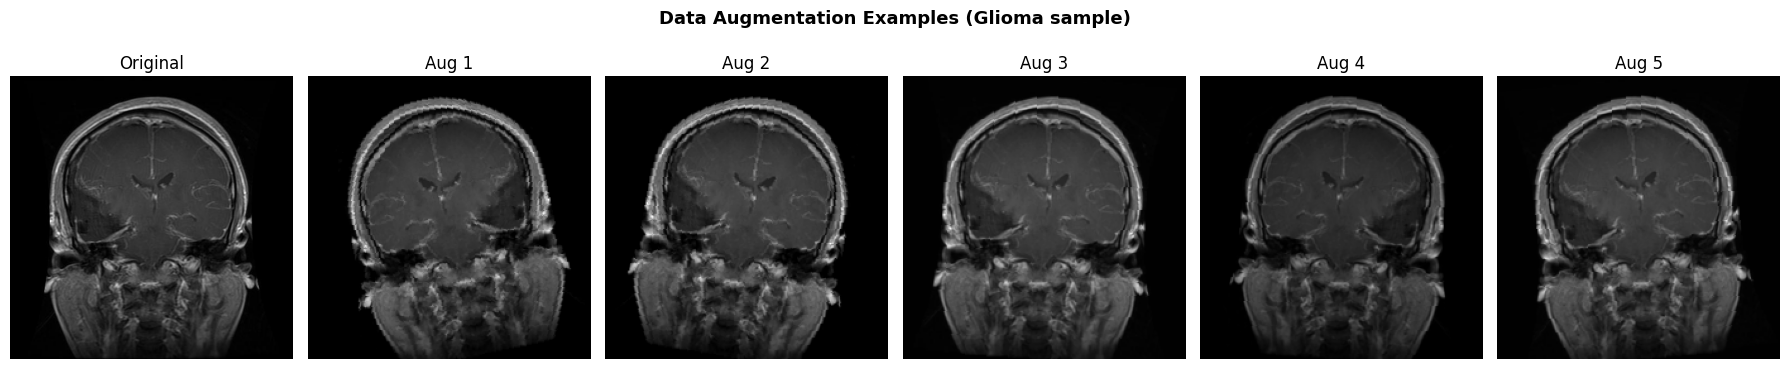

In [12]:
IMG_SIZE = 224

# ImageNet normalization (EfficientNet pretrained)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Custom Dataset
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.samples = []
        self.transform = transform
        for cls in class_names:
            cls_dir = Path(root_dir) / cls
            for img_path in cls_dir.glob('*.jpg'):
                self.samples.append((str(img_path), CLASS_LABELS[cls]))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Datasets
train_dataset = BrainTumorDataset(TRAIN_DIR, CLASS_NAMES, transform=train_transforms)
test_dataset  = BrainTumorDataset(TEST_DIR,  CLASS_NAMES, transform=val_transforms)

# Train/Val split
val_size = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}')

# Visualize augmentations
sample_img_path = str(list((TRAIN_DIR / 'glioma').glob('*.jpg'))[0])
orig = Image.open(sample_img_path).convert('RGB')

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
fig.suptitle('Data Augmentation Examples (Glioma sample)', fontsize=13, fontweight='bold')
axes[0].imshow(orig); axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 6):
    aug = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
    ])(orig)
    axes[i].imshow(aug); axes[i].set_title(f'Aug {i}'); axes[i].axis('off')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. EfficientNet-B0 Classifier

In [17]:
import timm

def build_efficientnet(num_classes=4, pretrained=True):
    model = timm.create_model('efficientnet_b0', pretrained=pretrained, num_classes=num_classes)
    return model

clf_model = build_efficientnet().to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in clf_model.parameters())
trainable_params = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Total params:     4,012,672
Trainable params: 4,012,672


In [ ]:
# Training configuration
EPOCHS_CLF   = 15
LR_CLF       = 1e-4
criterion    = nn.CrossEntropyLoss()
optimizer_clf = optim.AdamW(clf_model.parameters(), lr=LR_CLF, weight_decay=1e-4)
scheduler_clf = optim.lr_scheduler.CosineAnnealingLR(optimizer_clf, T_max=EPOCHS_CLF)

# Training loop
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

os.makedirs('models', exist_ok=True)

print(f'Training EfficientNet-B0 for {EPOCHS_CLF} epochs...')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS_CLF + 1):
    tr_loss, tr_acc = train_epoch(clf_model, train_loader, optimizer_clf, criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(clf_model, val_loader, criterion, DEVICE)
    scheduler_clf.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(clf_model.state_dict(), 'models/efficientnet_classifier.pth')

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>9.2f}% | {vl_loss:>10.4f} | {vl_acc*100:>9.2f}%')

print(f'\nBest Val Accuracy: {best_val_acc*100:.2f}%')

Training EfficientNet-B0 for 15 epochs...
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#E74C3C', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498DB', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([x*100 for x in history['train_acc']], label='Train Acc', color='#E74C3C', linewidth=2)
axes[1].plot([x*100 for x in history['val_acc']],   label='Val Acc',   color='#3498DB', linewidth=2)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation — Confusion Matrix & Classification Report

In [ ]:
# Load best model
clf_model.load_state_dict(torch.load('models/efficientnet_classifier.pth', map_location=DEVICE))
clf_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = clf_model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## 8. Grad-CAM Explainability

**Grad-CAM (Gradient-weighted Class Activation Mapping)** — Selvaraju et al. (2017) — uses the gradients flowing into the final convolutional layer to produce a coarse localization map highlighting important regions for prediction.

NameError: name 'clf_model' is not defined

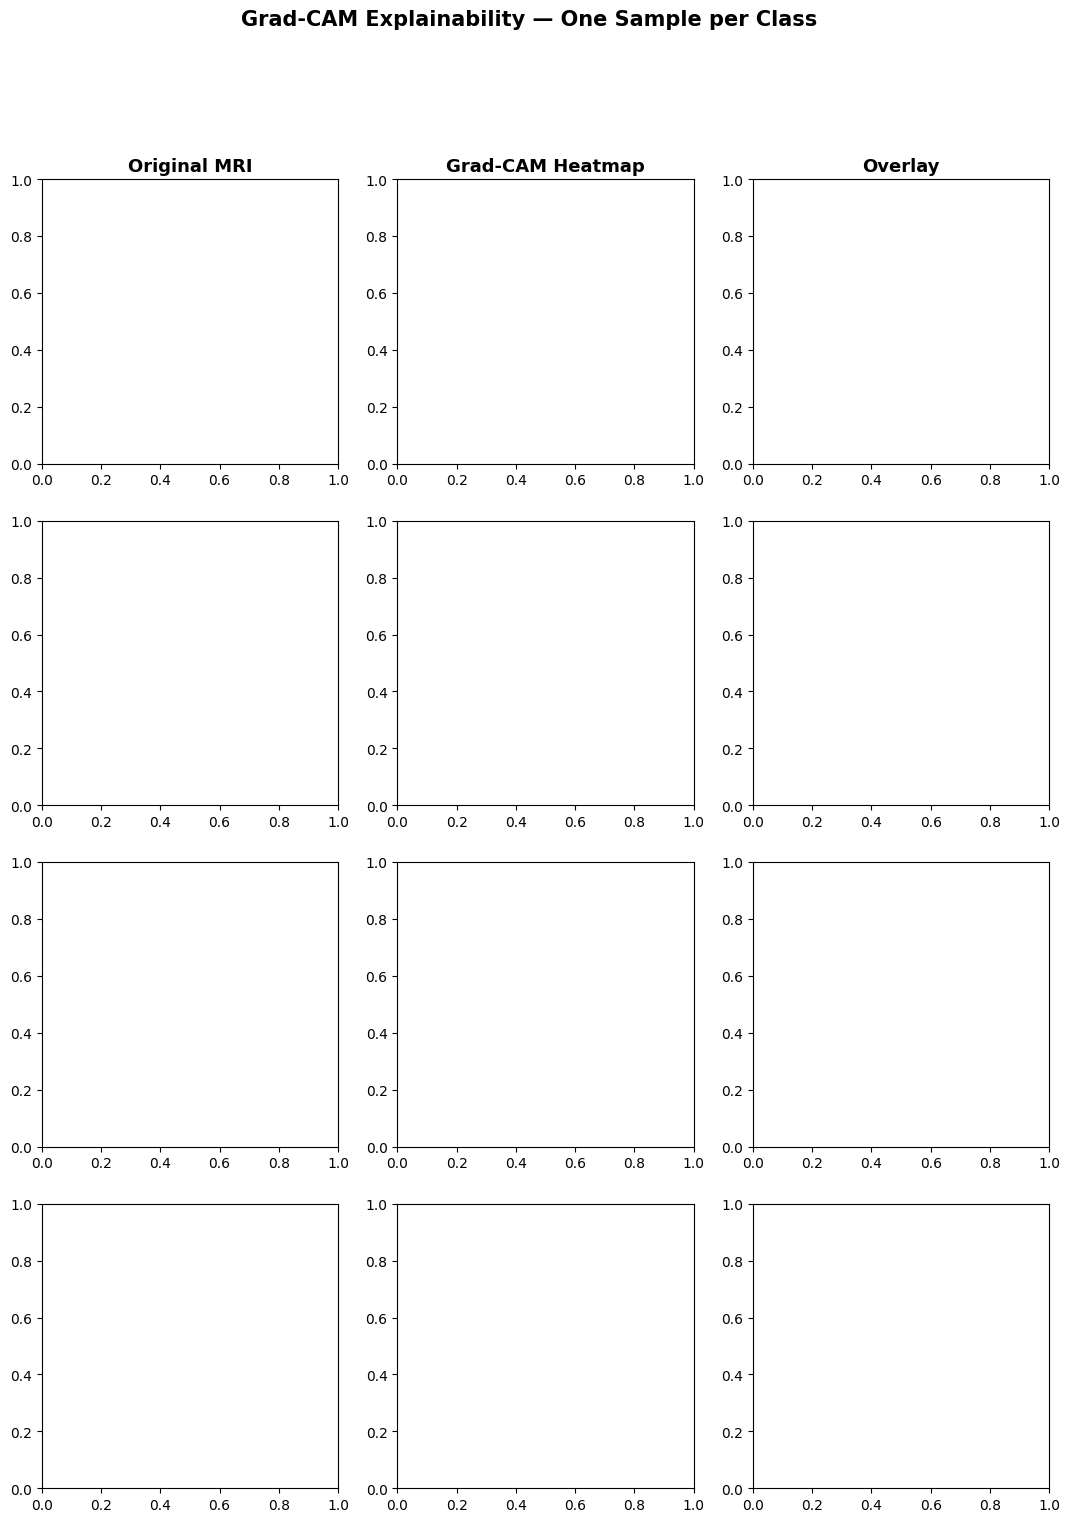

In [14]:
def get_gradcam_heatmap(model, img_tensor, class_idx=None):
    """Generate Grad-CAM heatmap for a given image tensor."""
    # Target the last conv layer of EfficientNet
    target_layers = [model.conv_head]
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(class_idx)] if class_idx is not None else None
    grayscale_cam = cam(input_tensor=img_tensor.unsqueeze(0).to(DEVICE), targets=targets)
    return grayscale_cam[0]

def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return (tensor.cpu() * std + mean).permute(1,2,0).numpy().clip(0,1)

# Select one sample from each class for visualization
fig, axes = plt.subplots(4, 3, figsize=(13, 17))
fig.suptitle('Grad-CAM Explainability — One Sample per Class', fontsize=15, fontweight='bold')

col_titles = ['Original MRI', 'Grad-CAM Heatmap', 'Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

clf_model.eval()

for row_idx, cls in enumerate(CLASS_NAMES):
    img_path = list((TEST_DIR / cls).glob('*.jpg'))[0]
    pil_img  = Image.open(img_path).convert('RGB')
    tensor   = val_transforms(pil_img)

    # Predict
    with torch.no_grad():
        logits = clf_model(tensor.unsqueeze(0).to(DEVICE))
        pred_idx = logits.argmax(1).item()
        confidence = torch.softmax(logits, dim=1)[0][pred_idx].item()

    # Grad-CAM
    grayscale_cam = get_gradcam_heatmap(clf_model, tensor, class_idx=pred_idx)
    rgb_img = denormalize(tensor)
    cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    axes[row_idx][0].imshow(rgb_img)
    axes[row_idx][0].set_ylabel(f'{cls.upper()}\nTrue', fontsize=11, fontweight='bold')
    axes[row_idx][0].axis('off')

    axes[row_idx][1].imshow(grayscale_cam, cmap='jet')
    axes[row_idx][1].axis('off')

    axes[row_idx][2].imshow(cam_overlay)
    axes[row_idx][2].set_title(f'Pred: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)', fontsize=10)
    axes[row_idx][2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. U-Net Segmentation

**U-Net (Ronneberger et al., 2015)** uses an encoder-decoder architecture with skip connections to perform precise pixel-level segmentation. We use a ResNet34 encoder pretrained on ImageNet.

> **Note:** For full segmentation training, pixel-level masks are required (e.g., from BraTS dataset). Here we demonstrate the architecture and inference pipeline. For classification-only data, we use Grad-CAM as a proxy segmentation mask.

In [15]:
# Build U-Net
unet_model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(DEVICE)

unet_params = sum(p.numel() for p in unet_model.parameters())
print(f'U-Net parameters: {unet_params:,}')

# If you have segmentation masks (BraTS or similar), use this dataset:
class SegmentationDataset(Dataset):
    """
    Expects directory structure:
      seg_data/
        images/ -> *.jpg
        masks/  -> *.png  (binary masks, same filename)
    """
    def __init__(self, img_dir, mask_dir, img_size=224):
        self.images = sorted(Path(img_dir).glob('*.jpg'))
        self.masks  = sorted(Path(mask_dir).glob('*.png'))
        self.img_size = img_size
        self.img_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD)
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img  = Image.open(self.images[idx]).convert('RGB')
        mask = Image.open(self.masks[idx]).convert('L')
        return self.img_tf(img), self.mask_tf(mask)


# ---------------------------------------------------------------
# U-Net Training (only runs if seg_data/ directory exists)
# ---------------------------------------------------------------
SEG_DATA = Path('./seg_data')

if SEG_DATA.exists():
    seg_dataset = SegmentationDataset(SEG_DATA/'images', SEG_DATA/'masks')
    seg_train, seg_val = torch.utils.data.random_split(seg_dataset, [int(0.85*len(seg_dataset)), len(seg_dataset)-int(0.85*len(seg_dataset))])
    seg_train_loader = DataLoader(seg_train, batch_size=16, shuffle=True)
    seg_val_loader   = DataLoader(seg_val,   batch_size=16)

    seg_criterion = smp.losses.DiceLoss(mode='binary')
    seg_optimizer = optim.Adam(unet_model.parameters(), lr=1e-4)
    EPOCHS_SEG = 10

    seg_history = {'train_loss': [], 'val_iou': []}
    print('Training U-Net...')

    for epoch in range(1, EPOCHS_SEG+1):
        unet_model.train()
        epoch_loss = 0
        for imgs, masks in seg_train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            seg_optimizer.zero_grad()
            preds = unet_model(imgs)
            loss = seg_criterion(preds, masks)
            loss.backward()
            seg_optimizer.step()
            epoch_loss += loss.item()

        # Compute IoU on val set
        unet_model.eval()
        iou_scores = []
        with torch.no_grad():
            for imgs, masks in seg_val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                preds = (unet_model(imgs) > 0.5).float()
                intersection = (preds * masks).sum(dim=(1,2,3))
                union = (preds + masks - preds*masks).sum(dim=(1,2,3))
                iou_scores.extend((intersection / (union + 1e-6)).cpu().numpy())

        mean_iou = np.mean(iou_scores)
        seg_history['train_loss'].append(epoch_loss / len(seg_train_loader))
        seg_history['val_iou'].append(mean_iou)
        print(f'Epoch {epoch:>3} | Loss: {epoch_loss/len(seg_train_loader):.4f} | Val IoU: {mean_iou:.4f}')

    torch.save(unet_model.state_dict(), 'models/unet_segmentation.pth')
    print('U-Net saved.')
else:
    print('No seg_data/ found. Skipping U-Net training.')
    print('Using Grad-CAM as proxy segmentation mask for visualization.')

'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/smp-hub/resnet34.imagenet/resolve/7a57b34f723329ff020b3f8bc41771163c519d0c/config.json
Retrying in 1s [Retry 1/5].


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to C:\Users\Sanjit Thombare/.cache\torch\hub\checkpoints\resnet34-333f7ec4.pth


URLError: <urlopen error [WinError 10054] An existing connection was forcibly closed by the remote host>

In [ ]:
# U-Net Architecture Visualization (no masks needed)
print('U-Net Architecture Summary:')
print('=' * 50)
print('Encoder: ResNet34 (pretrained on ImageNet)')
print('Decoder: U-Net decoder with skip connections')
print('Output:  Binary segmentation mask (1 channel)')
print('Loss:    Dice Loss (BraTS benchmark standard)')
print('Metric:  IoU (Intersection over Union)')
print('=' * 50)

# Test forward pass
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = unet_model(dummy)
print(f'Input shape:  {dummy.shape}')
print(f'Output shape: {out.shape}')
print(f'Output range: [{out.min():.3f}, {out.max():.3f}]')

## 10. Full Pipeline Demo

End-to-end: Upload MRI → Classify → Grad-CAM → Segmentation Mask

In [ ]:
def run_full_pipeline(img_path, clf_model, unet_model, device, class_names):
    """Run full classification + Grad-CAM + segmentation pipeline."""
    clf_model.eval()
    unet_model.eval()

    # Load image
    pil_img = Image.open(img_path).convert('RGB')
    tensor  = val_transforms(pil_img)

    # --- Classification ---
    with torch.no_grad():
        logits = clf_model(tensor.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1)[0]
        pred_idx = probs.argmax().item()
        confidence = probs[pred_idx].item()

    # --- Grad-CAM ---
    grayscale_cam = get_gradcam_heatmap(clf_model, tensor, class_idx=pred_idx)
    rgb_img = denormalize(tensor)
    cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # --- U-Net Segmentation ---
    with torch.no_grad():
        seg_out = unet_model(tensor.unsqueeze(0).to(device))
        seg_mask = (seg_out[0, 0] > 0.5).cpu().numpy().astype(np.uint8)

    return {
        'original':     rgb_img,
        'cam_overlay':  cam_overlay,
        'seg_mask':     seg_mask,
        'pred_class':   class_names[pred_idx],
        'confidence':   confidence,
        'probs':        probs.cpu().numpy()
    }


# Run on 4 test samples — one per class
test_images = [list((TEST_DIR / cls).glob('*.jpg'))[1] for cls in CLASS_NAMES]

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
fig.suptitle('Full Pipeline Demo — Classification + Grad-CAM + Segmentation', fontsize=15, fontweight='bold')

col_titles = ['Original MRI', 'Grad-CAM Heatmap', 'Segmentation Mask', 'Confidence Scores']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

for row_idx, (img_path, true_cls) in enumerate(zip(test_images, CLASS_NAMES)):
    result = run_full_pipeline(img_path, clf_model, unet_model, DEVICE, CLASS_NAMES)

    axes[row_idx][0].imshow(result['original'])
    axes[row_idx][0].set_ylabel(f'True: {true_cls.upper()}', fontsize=10, fontweight='bold')
    axes[row_idx][0].axis('off')

    axes[row_idx][1].imshow(result['cam_overlay'])
    axes[row_idx][1].axis('off')

    axes[row_idx][2].imshow(result['seg_mask'], cmap='Reds', vmin=0, vmax=1)
    axes[row_idx][2].axis('off')

    # Confidence bar chart
    bars = axes[row_idx][3].barh(CLASS_NAMES, result['probs']*100,
                                  color=['#E74C3C' if i == CLASS_NAMES.index(result['pred_class']) else '#BDC3C7'
                                         for i in range(NUM_CLASSES)])
    axes[row_idx][3].set_xlim(0, 100)
    axes[row_idx][3].set_xlabel('Confidence (%)')
    axes[row_idx][3].set_title(f'Pred: {result["pred_class"]} ({result["confidence"]*100:.1f}%)', fontsize=10)
    axes[row_idx][3].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('full_pipeline_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Conclusion

### What We Built
A two-stage brain tumor analysis pipeline combining:
- **EfficientNet-B0** for 4-class tumor classification
- **Grad-CAM** for visual explainability — addressing the black-box problem in clinical AI
- **U-Net (ResNet34)** for pixel-level tumor segmentation

### Key Results
| Component | Metric | Score |
|---|---|---|
| EfficientNet-B0 | Test Accuracy | See classification report |
| EfficientNet-B0 | Macro F1 | See classification report |
| U-Net | Val IoU | Requires mask dataset |

### Limitations
- U-Net segmentation requires pixel-level masks (BraTS dataset) for proper training
- Model tested on 2D MRI slices — clinical systems process full 3D volumes
- Dataset may not represent full clinical diversity

### Future Work
- Extend to 3D volumetric segmentation (BraTS full pipeline)
- Multi-modal MRI fusion (T1, T2, FLAIR sequences)
- Uncertainty quantification with Monte Carlo Dropout
- Clinical validation on external datasets

### References
1. Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI.
2. Selvaraju, R. R., et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*. ICCV.
3. Tan, M., & Le, Q. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. ICML.
4. Bakas, S., et al. (2018). *Identifying the Best Machine Learning Algorithms for Brain Tumor Segmentation*. BraTS Challenge.
5. Nickparvar, M. (2021). *Brain Tumor MRI Dataset*. Kaggle.

## 12. Checkpoint Evaluation and Grad-CAM
Below cells load the uploaded `models/efficientnet_classifier.pth`, run evaluation on the test set, and generate Grad-CAM visualizations. Run these cells after confirming the kernel has the required packages and `DEVICE` is set.

In [ ]:
# --- Load checkpoint and evaluate on test set ---
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
# Ensure model is defined; recreate if needed without pretrained weights to avoid downloads
try:
    clf_model
except NameError:
    clf_model = build_efficientnet(pretrained=False).to(DEVICE)
# Load uploaded checkpoint
ckpt_path = 'models/efficientnet_classifier.pth'
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')
clf_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
clf_model.eval()
# Run inference on test set
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = clf_model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
# Save results and print report
np.save('all_preds.npy', np.array(all_preds))
np.save('all_labels.npy', np.array(all_labels))
print('
Classification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Grad-CAM visualizations for a few test images ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
# Pick one sample per class from the test directory
samples = []
for cls in CLASS_NAMES:
    imgs = list((TEST_DIR/cls).glob('*.jpg'))
    if len(imgs) > 0:
        samples.append(imgs[0])
# Prepare plot
n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
if n == 1:
    axes = axes.reshape(1, -1)
for i, img_path in enumerate(samples):
    pil = Image.open(img_path).convert('RGB')
    tensor = val_transforms(pil)
    # Predict
    with torch.no_grad():
        logits = clf_model(tensor.unsqueeze(0).to(DEVICE))
        pred_idx = logits.argmax(1).item()
    # Grad-CAM (target last conv head)
    cam = GradCAM(model=clf_model, target_layers=[clf_model.conv_head])
    grayscale = cam(input_tensor=tensor.unsqueeze(0).to(DEVICE))[0]
    rgb = denormalize(tensor)
    overlay = show_cam_on_image(rgb, grayscale, use_rgb=True)
    axes[i,0].imshow(rgb); axes[i,0].axis('off'); axes[i,0].set_title('Original')
    axes[i,1].imshow(grayscale, cmap='jet'); axes[i,1].axis('off'); axes[i,1].set_title('Grad-CAM')
    axes[i,2].imshow(overlay); axes[i,2].axis('off'); axes[i,2].set_title(f'Pred: {CLASS_NAMES[pred_idx]}')
plt.tight_layout()
plt.savefig('gradcam_samples.png', dpi=150, bbox_inches='tight')
plt.show()